In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split

### Load Dataset

In [4]:
orig_df = pd.read_csv("bank_edited.csv")
orig_df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


In [5]:
orig_df['y'] = orig_df['y'].map({'yes': 1, 'no': 0})
orig_df['y'].value_counts()

y
0    4000
1     521
Name: count, dtype: int64

In [6]:
orig_y = orig_df['y']
orig_y

0       0
1       0
2       0
3       0
4       0
       ..
4516    0
4517    0
4518    0
4519    0
4520    0
Name: y, Length: 4521, dtype: int64

In [7]:
df = orig_df.copy()

In [8]:
orig_X = df.drop(['y'], axis=1)
orig_X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

In [9]:
orig_X.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object

In [10]:
# Finding categorical variables
cat_features = orig_X.select_dtypes(include=["object", "category"]).columns
cat_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [11]:
# Finding numerical variables
num_features = orig_X.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [12]:
num_orig_X = df[num_features]
num_orig_X.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

### Data Preprocessing

#### Scaling

In [13]:
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

### Encoding Categorical Data

In [14]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

In [15]:
# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Handling Imbalance 

In [16]:
# Undersampling
def undersampling(X,y):
    from imblearn.under_sampling import RandomUnderSampler
    X_res, y_res = RandomUnderSampler().fit_resample(X, y)
    return X_res, y_res

# Oversampling
def oversampling(X,y):
    from imblearn.over_sampling import RandomOverSampler
    X_res, y_res = RandomOverSampler().fit_resample(X, y)
    return X_res, y_res

# SMOTE
def smote(X,y):
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE().fit_resample(X, y)
    return X_res, y_res

### Performance Evaluation

In [17]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [18]:
def plot_roc_auc(y_true, y_pred):
    from sklearn.metrics import roc_curve, roc_auc_score
    import matplotlib.pyplot as plt

    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (AUC = {auc:.3f})")
    plt.show()

    return auc

### Experiments: Models

In [19]:
print('job: ',orig_X['job'].unique())
print('marital: ',orig_X['marital'].unique())
print('education: ',orig_X['education'].unique())
print('default: ',orig_X['default'].unique())
print('housing: ',orig_X['housing'].unique())
print('loan: ',orig_X['loan'].unique())
print('contact: ',orig_X['contact'].unique())
print('month: ',orig_X['month'].unique())
print('poutcome: ',orig_X['poutcome'].unique())

job:  ['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']
marital:  ['married' 'single' 'divorced']
education:  ['primary' 'secondary' 'tertiary' 'unknown']
default:  ['no' 'yes']
housing:  ['no' 'yes']
loan:  ['no' 'yes']
contact:  ['cellular' 'unknown' 'telephone']
month:  ['oct' 'may' 'apr' 'jun' 'feb' 'aug' 'jan' 'jul' 'nov' 'sep' 'mar' 'dec']
poutcome:  ['unknown' 'failure' 'other' 'success']


In [20]:
X = orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Categorical Data Encoding ##############
## Nominal -> binary classes -> Binay mapping
X_train['default'] = X_train['default'].map({'yes': 1, 'no': 0})
X_test['default'] = X_test['default'].map({'yes': 1, 'no': 0})
X_train['housing'] = X_train['housing'].map({'yes': 1, 'no': 0})
X_test['housing'] = X_test['housing'].map({'yes': 1, 'no': 0})
X_train['loan'] = X_train['loan'].map({'yes': 1, 'no': 0})
X_test['loan'] = X_test['loan'].map({'yes': 1, 'no': 0})
#######################################################
## Nominal -> one hot 
encoded_vars = ['job', 'marital','contact','poutcome']
X_train = onehot_encoder_selected(X_train, encoded_vars)
X_test = onehot_encoder_selected(X_test, encoded_vars)
#######################################################
## Ordinal -> Ordinal Encoder
encoded_var = 'education'
encode_order = ['unknown', 'primary', 'secondary', 'tertiary']  # Item1 = 0, Item2= 1, ... 
X_train = ordinal_encoder(X_train, encoded_var, encode_order)
X_test = ordinal_encoder(X_test, encoded_var, encode_order)

encoded_var = 'month'
encode_order = ['','jan', 'feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
X_train = ordinal_encoder(X_train, encoded_var, encode_order)
X_test = ordinal_encoder(X_test, encoded_var, encode_order)
#######################################################

############## Imbalance Handling here ##############
# Smote Example
X_train, y_train = smote(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()
#######################################################

base_X_train = X_train.copy()
base_X_test = X_test.copy()

base_X_train.head()

(6386, 34) (6386,)


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,34,3.0,0,262,0,0,20,11.0,371,1,...,True,False,False,True,False,False,False,False,False,True
1,32,3.0,0,2349,0,0,14,8.0,134,5,...,False,True,False,True,False,False,False,False,False,True
2,34,2.0,0,1076,0,0,8,8.0,70,2,...,False,False,True,True,False,False,False,False,False,True
3,31,3.0,0,156,0,0,13,8.0,657,7,...,False,True,False,True,False,False,False,False,False,True
4,46,1.0,0,258,1,0,27,5.0,217,1,...,False,True,False,False,False,True,False,False,False,True


#### Logistic Regression: Binary Classes

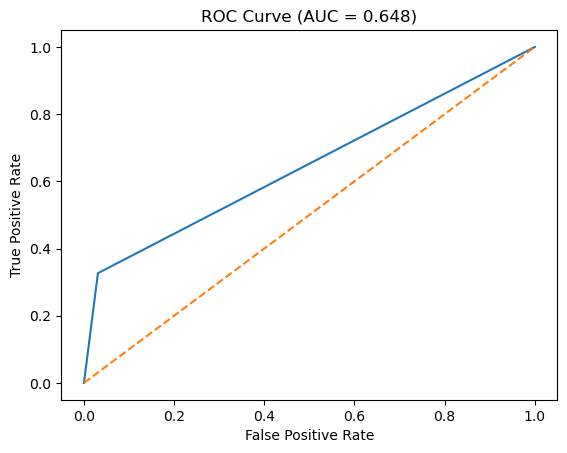

0.6477758389601194
[[782  25]
 [ 66  32]]
0.8994475138121547 0.7417866600463423 0.6477758389601194 0.6789591657733164


In [21]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling 
X_train, X_test = scale_standard(X_train, X_test)

#######################################################
# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

#### K-Nearest Neighbors Model (KNN)

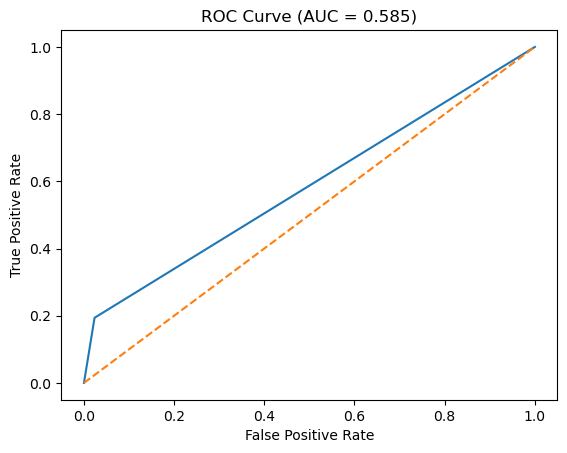

0.5851667804668335
[[788  19]
 [ 79  19]]
0.8917127071823204 0.7044405997693195 0.5851667804668336 0.6104346756623796


In [22]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling 
# Scaling 
X_train, X_test = scale_standard(X_train, X_test)

#######################################################
# Construct a model
selected_k = 2
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = selected_k, metric = 'minkowski', p = 2) # minkowski metric where p = 2 is euclidean distance
model.fit(X_train, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

### Support Vector Model (SVM)

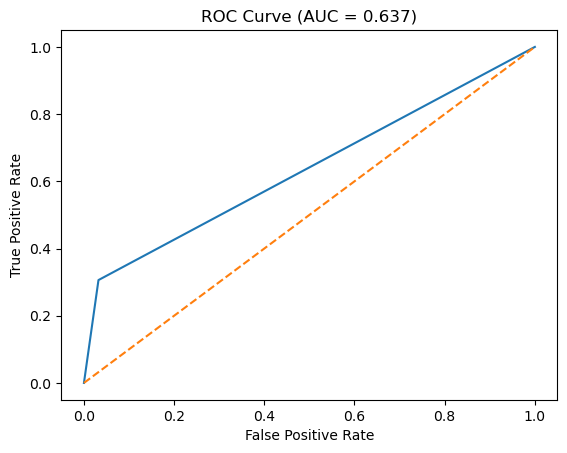

0.6369521786409732
[[781  26]
 [ 68  30]]
0.8961325966850828 0.7278100286050816 0.6369521786409731 0.6664235522931174


In [23]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling 
# Scaling 
X_train, X_test = scale_standard(X_train, X_test)

#######################################################
# Construct a model
from sklearn.svm import SVC
model = SVC(kernel = 'rbf', random_state = 0)  
model.fit(X_train, y_train)

# Other options for kernel are 'poly', 'rbf', 'sigmoid'
# Read more about how to choose kernel at 
# https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

#### Decision Tree: Tree based model 

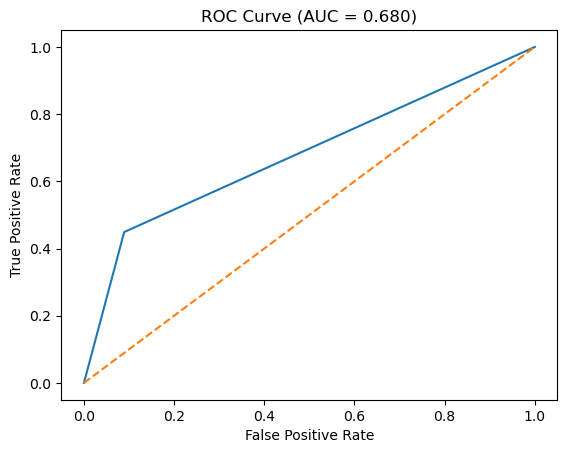

0.6798801304908582
[[735  72]
 [ 54  44]]
0.8607734806629834 0.6554346400944014 0.679880130490858 0.6661337924249877


In [24]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
model.fit(X_train, y_train)

# Beside 'gini', other criterion is 'entropy'
# Read more about gini and entropy criterion at:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# https://www.geeksforgeeks.org/gini-impurity-and-entropy-in-decision-tree-ml/
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

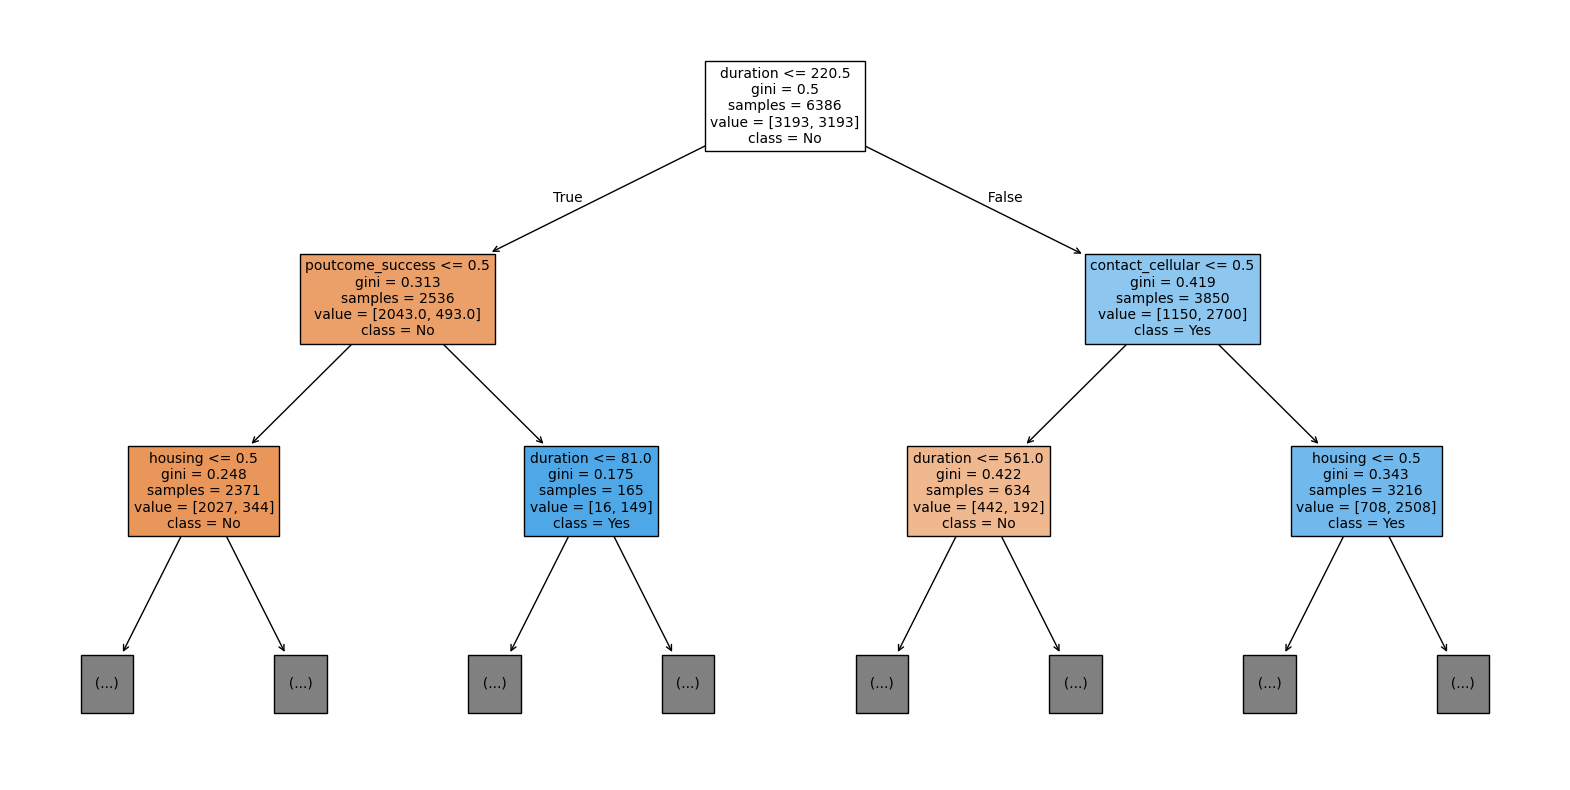

In [25]:
# Plot the decision tree
our_class_names = ['No', 'Yes']
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=base_X_train.columns,
          class_names=our_class_names,
          filled=True,   # paint nodes according to class
          fontsize=10,
          max_depth=2    # tree depth parameter
          )
plt.show()

In [26]:
# Create feature importance dataframe
feature_importance_df = pd.DataFrame({'feature': base_X_train.columns,
                                      'importance': model.feature_importances_
                                     })
# Sort importance values
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)  
feature_importance_df

,feature,importance
8,duration,0.371469
7,month,0.103908
27,contact_cellular,0.078537
32,poutcome_success,0.071333
3,balance,0.054701
4,housing,0.054161
6,day,0.038950
0,age,0.037027
1,education,0.027982
10,pdays,0.017675


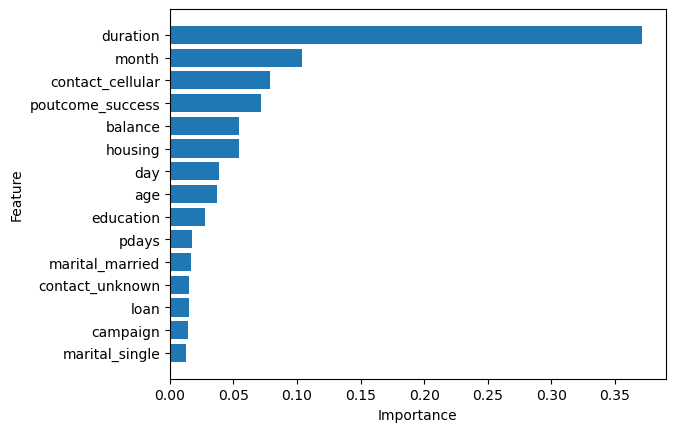

In [27]:
# Plot feature importance from decision tree
num_top_features = 15  # plot number of important featurs up to this value

plt.figure()
plt.barh(
    feature_importance_df.head(num_top_features)['feature'],
    feature_importance_df.head(num_top_features)['importance']
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

#### Random Forest: Tree based model

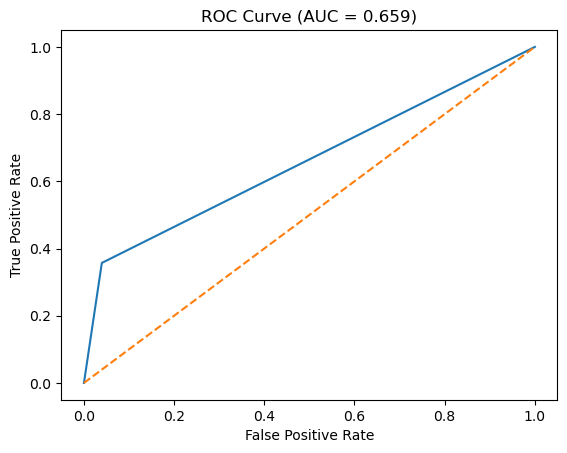

0.6587449106036467
[[775  32]
 [ 63  35]]
0.8950276243093923 0.7236045310440637 0.6587449106036467 0.6832458321820024


In [28]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
selected_n = 100  # n_estimators  = number of decision trees used in random forest model, default value = 100
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = selected_n, criterion = 'gini', random_state = 0)  
model.fit(X_train, y_train)
# Read more about other parameters at
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

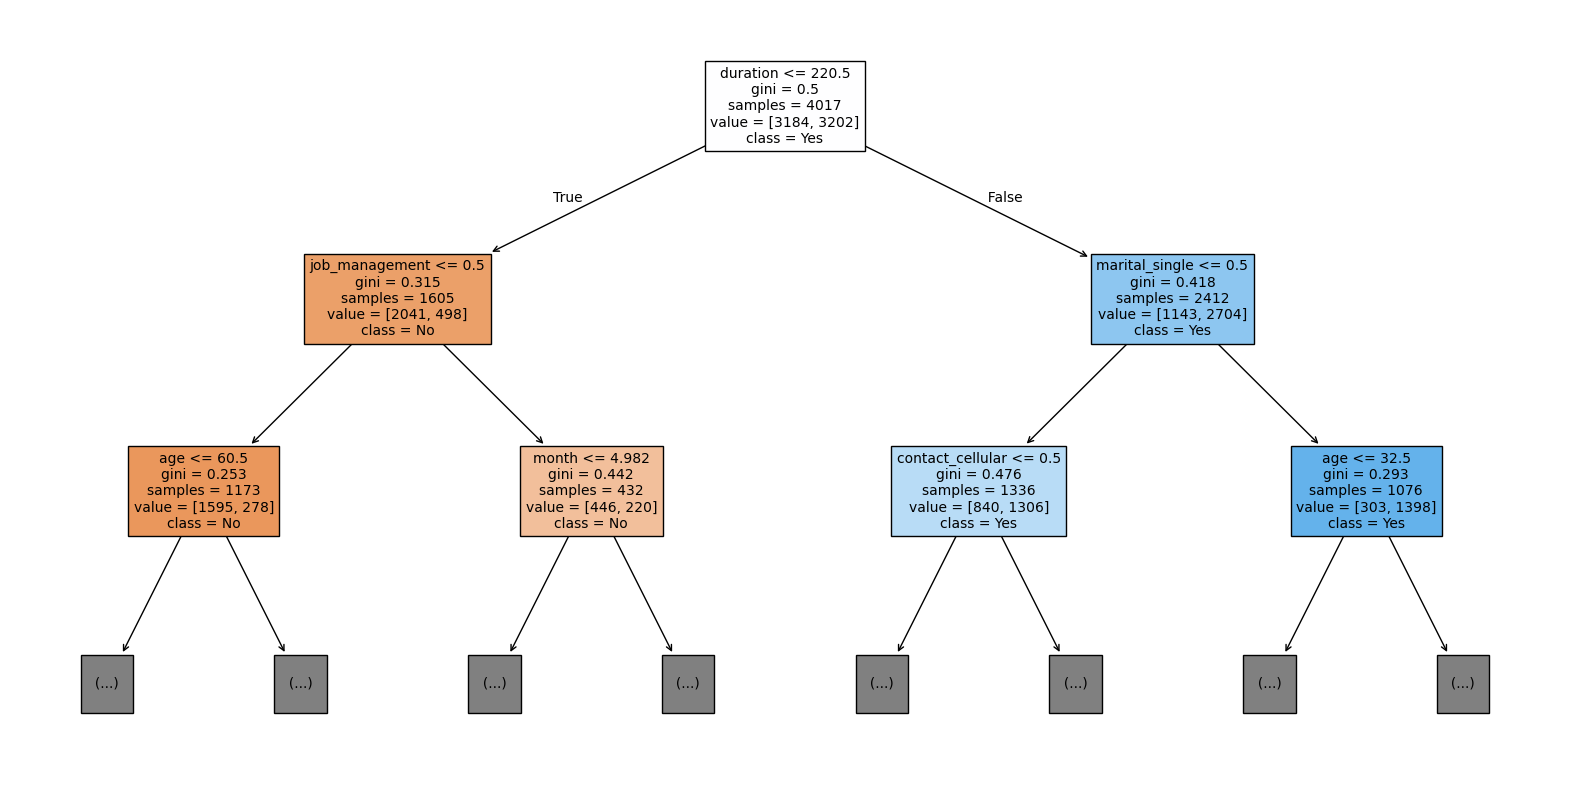

In [29]:
# Can plot individual decision tree from random forest

# Plot the decision tree
tree_index = 0  # select which tree index to plot, starting from 0
our_class_names=['No', 'Yes']
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[tree_index],
          feature_names=base_X_train.columns,
          class_names=our_class_names,
          filled=True,   # paint nodes according to class
          fontsize=10,
          max_depth=2    # tree depth parameter
          )
plt.show()

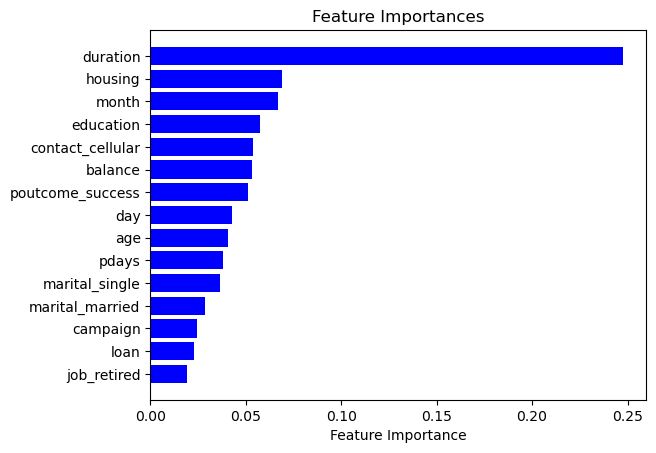

In [30]:
# Plot feature importance from random forest model
num_top_features = 15  # plot number of important featurs up to this value

feature_names = base_X_train.columns
importances = model.feature_importances_
indices = np.argsort(importances)[-num_top_features:]  # sort top n features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.show()

### Neural Network

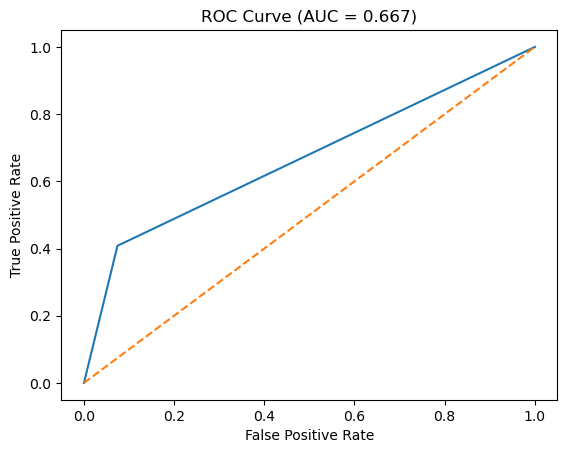

0.6669069114634701
[[747  60]
 [ 58  40]]
0.8696132596685083 0.6639751552795031 0.6669069114634701 0.6654197057422864


In [31]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling 
X_train, X_test = scale_standard(X_train, X_test)

#######################################################
# Construct a model
hidden_layer_info = (15,10)
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=hidden_layer_info, activation='relu', max_iter=10000, random_state=1)
model.fit(X_train, y_train)
# Read more about how to choose kernel at 
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)